In [1]:
# Libraries
import numpy as np
from numpy import trapezoid
from scipy.special import factorial, eval_hermite
import matplotlib.pyplot as plt

plt.style.use("dark_background")

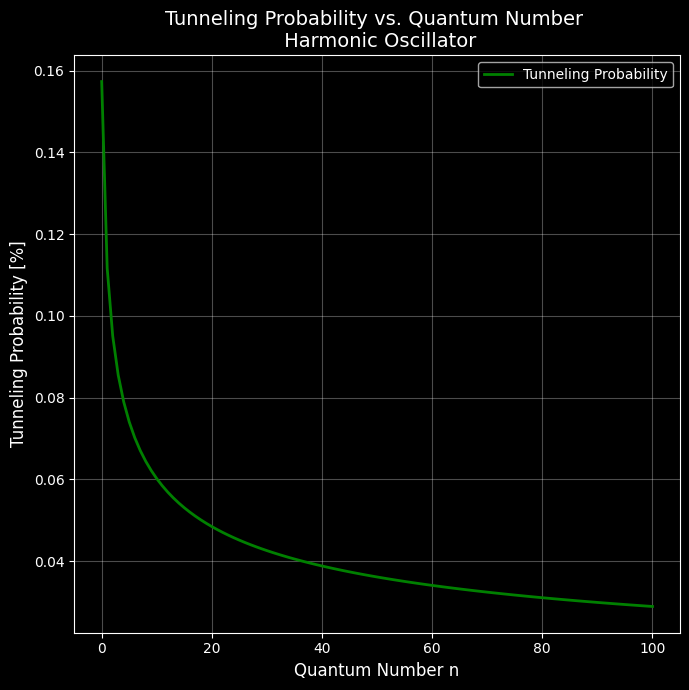

In [2]:
# Computing the probability chart of a quantum harmonic oscillator
tunnel = []

for n in range(0, 101, 1):
    
    turn_point = np.sqrt(2 * n + 1)
    x = np.linspace(turn_point, 5 * turn_point, 1_000)        
    wavefunction = (1.0 / (np.pi ** 0.25 * np.sqrt(2 ** n * factorial(n)))) * np.exp(- x ** 2 / 2) * eval_hermite(n, x)

    p = 2 * trapezoid((wavefunction ** 2), x)
    tunnel.append(p)

tunnel = np.array(tunnel)

plt.figure(figsize = (7, 7))
plt.plot(tunnel, 'g-', linewidth = 2, label = 'Tunneling Probability')
plt.xlabel('Quantum Number n', fontsize = 12)
plt.ylabel('Tunneling Probability [%]', fontsize = 12)
plt.title('Tunneling Probability vs. Quantum Number \n Harmonic Oscillator', fontsize = 14)
plt.grid(True, alpha = 0.3)
plt.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

In [3]:
from pysr import PySRRegressor # For symbolic regression (awesome!!)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [4]:
net = PySRRegressor( # Creating a basic PySSRegressor instance
    unary_operators = ["exp", "sqrt", "log"],
    progress = False,
    verbosity = 0,
    parsimony = 0.1,
    model_selection = 'accuracy',
    warm_start = False # Only for multiple training sessions
)

n_range = np.arange(0, 101, 1) # range of quantum numbers

# Training twice
net.fit(n_range.reshape(- 1, 1), tunnel, variable_names = ['n'])

,model_selection,'accuracy'
,binary_operators,None
,unary_operators,"['exp', 'sqrt', ...]"
,expression_spec,None
,niterations,100
,populations,31
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


In [5]:
net.score(n_range.reshape(- 1, 1), tunnel) # Score

0.9999386280579903

In [ ]:
net.latex() # Expression found (one of infinitely many possible)

'0.0101 + \\frac{0.209}{\\sqrt{n + 0.188} + 0.984}'

$$
    P(n) = 0.0101 + \frac{0.209}{\sqrt{n + 0.188} + 0.984}
$$

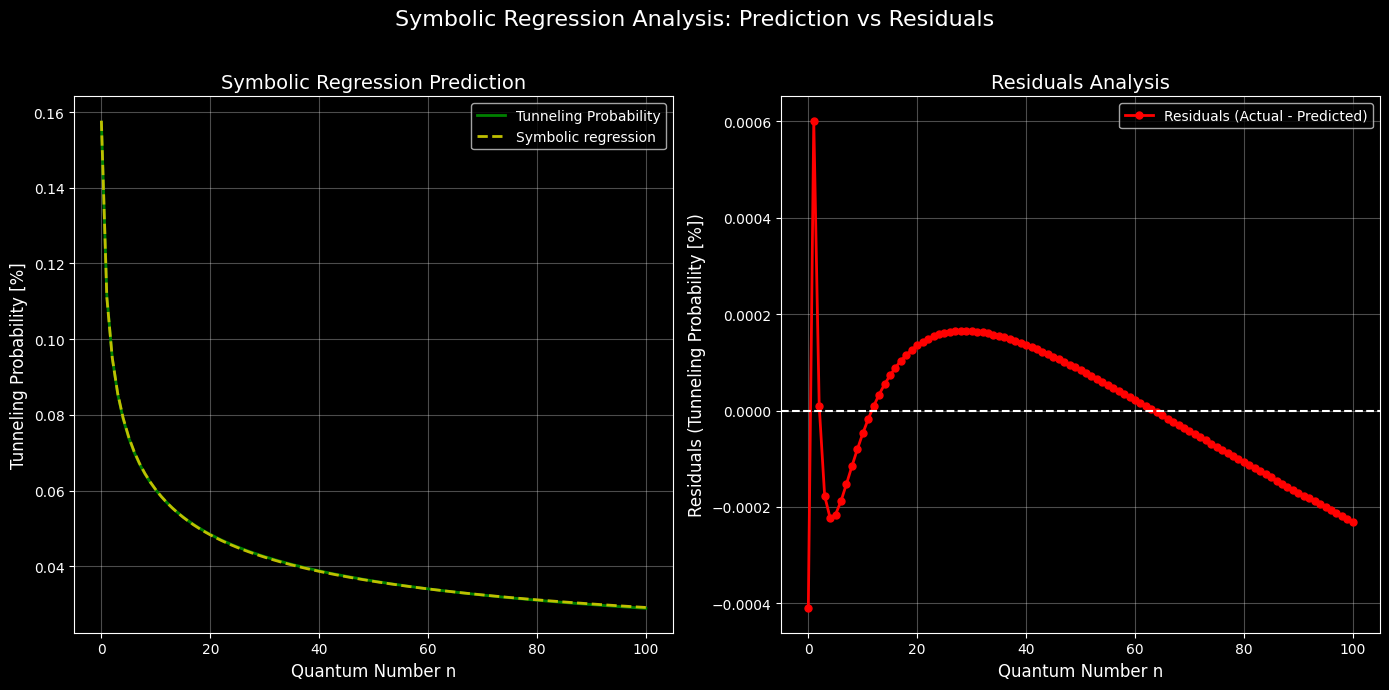

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 7), sharex = True)

# Left subplot: Fitting curve
pred = net.predict(n_range.reshape(- 1, 1))
ax1.plot(tunnel, 'g-', linewidth = 2, label = 'Tunneling Probability')
ax1.plot(pred, 'y--', linewidth = 2, label = 'Symbolic regression')
ax1.set_xlabel('Quantum Number n', fontsize = 12)
ax1.set_ylabel('Tunneling Probability [%]', fontsize = 12)
ax1.set_title('Symbolic Regression Prediction', fontsize = 14)
ax1.grid(True, alpha = 0.3)
ax1.legend(loc='upper right')

# Right subplot: Residuals
residuals = tunnel - pred
ax2.plot(n_range, residuals, 'r', linewidth = 2, label = 'Residuals (Actual - Predicted)', marker = 'o', markersize = 5)
ax2.axhline(y = 0, color = 'white', linestyle = '--', linewidth = 1.5)
ax2.set_xlabel('Quantum Number n', fontsize = 12)
ax2.set_ylabel('Residuals (Tunneling Probability [%])', fontsize = 12)
ax2.set_title('Residuals Analysis', fontsize = 14)
ax2.grid(True, alpha = 0.3)
ax2.legend(loc = 'best')

plt.suptitle('Symbolic Regression Analysis: Prediction vs Residuals', fontsize = 16, y = 0.98)
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

# **PySRRegressor API Reference v.1.5.9**

## **Model Configuration**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `model_selection` | Literal['best', 'accuracy', 'score'] | "best" | Final model selection criterion: 'accuracy' (lowest loss), 'score' (highest score), or 'best' (balanced approach) |
| `verbosity` | int | 1 | Print verbosity level (0 = minimal) |
| `print_precision` | int | 5 | Significant digits for printing floats |
| `progress` | bool | True | Use progress bar instead of stdout printing |
| `random_state` | int, RandomState, None | None | Seed for reproducible results |
| `deterministic` | bool | False | Ensure identical results across runs (requires parallelism="serial" and fixed random_state) |
| `warm_start` | bool | False | Continue from previous fit instead of fresh start |
| `run_id` | str | None | Unique run identifier (auto-generated if None) |
| `output_directory` | str | None | Base directory for output files (default: outputs/) |
| `update` | bool | False | Automatically update Julia packages when fit is called |

---

## **Expression Structure & Operators**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `binary_operators` | list[str], None | ["+", "-", "*", "/"] | Binary operators for search (e.g., ["+", "*", "pow"]) |
| `unary_operators` | list[str], None | None | Single-input operators (e.g., ["cos", "exp", "log"]) |
| `expression_spec` | AbstractExpressionSpec, None | ExpressionSpec() | Expression type specification (e.g., TemplateExpressionSpec) |
| `maxsize` | int | 30 | Maximum expression complexity |
| `maxdepth` | int | None | Maximum expression depth |
| `warmup_maxsize_by` | float, None | None | Gradually increase maxsize during training (fraction of training time) |
| `constraints` | dict[str, int or tuple], None | None | Complexity constraints per operator argument (e.g., {'pow': (-1, 1)}) |
| `nested_constraints` | dict[str, dict], None | None | Nesting limits for operator combinations |
| `dimensional_constraint_penalty` | float, None | 1000.0 | Penalty for dimensional analysis failures |
| `dimensionless_constants_only` | bool | False | Only search for dimensionless constants when using units |

---

## **Search Algorithm Control**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `niterations` | int | 100 | Algorithm iterations (equations migrate between populations each iteration) |
| `populations` | int | 31 | Number of parallel populations |
| `population_size` | int | 27 | Individuals per population |
| `max_evals` | int, None | None | Maximum total expression evaluations |
| `timeout_in_seconds` | float, None | None | Early stop after specified seconds |
| `early_stop_condition` | float or str, None | None | Early stop condition (loss value or Julia function string) |
| `ncycles_per_iteration` | int | 380 | Total mutations per 10 samples per iteration |
| `fraction_replaced` | float | 0.00036 | Population fraction replaced by migrating equations |
| `fraction_replaced_hof` | float | 0.0614 | Population fraction replaced by hall of fame migrants |
| `migration` | bool | True | Enable migration between populations |
| `hof_migration` | bool | True | Enable hall of fame migration |
| `topn` | int | 12 | Number of top individuals migrating from each population |

---

## **Mutation & Genetic Operations**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `weight_add_node` | float | 2.47 | Relative likelihood: add node |
| `weight_insert_node` | float | 0.0112 | Relative likelihood: insert node |
| `weight_delete_node` | float | 0.87 | Relative likelihood: delete node |
| `weight_do_nothing` | float | 0.273 | Relative likelihood: no change |
| `weight_mutate_constant` | float | 0.0346 | Relative likelihood: perturb constant |
| `weight_mutate_operator` | float | 0.293 | Relative likelihood: swap operator |
| `weight_swap_operands` | float | 0.198 | Relative likelihood: swap binary operands |
| `weight_rotate_tree` | float | 4.26 | Relative likelihood: tree rotation |
| `weight_randomize` | float | 0.000502 | Relative likelihood: completely regenerate equation |
| `weight_simplify` | float | 0.00209 | Relative likelihood: simplify constant parts |
| `weight_optimize` | float | 0.0 | Relative likelihood: optimize constants (as mutation) |
| `crossover_probability` | float | 0.0259 | Absolute probability of crossover (vs mutation) |
| `skip_mutation_failures` | bool | True | Skip failed mutations rather than resampling |
| `perturbation_factor` | float | 0.129 | Maximum constant perturbation factor (multiply or divide) |
| `probability_negate_constant` | float | 0.00743 | Probability of negating a constant during mutation |

---

## **Loss Functions & Optimization**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `elementwise_loss` | str, None | "L2DistLoss()" | Julia code for elementwise loss (e.g., "L1DistLoss()", "HuberLoss(d)") |
| `loss_function` | str, None | None | Julia code for full custom objective function |
| `loss_function_expression` | str, None | None | Custom loss function taking expression object as first argument |
| `loss_scale` | Literal['log', 'linear'] | "log" | Loss scaling for scores: "log" (non-negative) or "linear" (any values) |
| `should_simplify` | bool | True | Enable algebraic simplification during search |
| `should_optimize_constants` | bool | True | Numerically optimize constants each iteration |
| `optimizer_algorithm` | Literal['BFGS', 'NelderMead'] | "BFGS" | Constant optimization algorithm |
| `optimizer_nrestarts` | int | 2 | Restarts for constant optimization |
| `optimizer_f_calls_limit` | int, None | 10000 | Function call limit for optimizer |
| `optimize_probability` | float | 0.14 | Probability of optimizing constants per iteration |
| `optimizer_iterations` | int | 8 | Iterations for constants optimizer |
| `autodiff_backend` | Literal['Zygote'], None | None | Automatic differentiation backend (only "Zygote" supported) |

---

## **Complexity & Parsimony**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `complexity_of_operators` | dict[str, int or float], None | None | Custom operator complexities (e.g., {"sin": 2}) |
| `complexity_of_constants` | int or float, None | 1 | Complexity per constant |
| `complexity_of_variables` | int, float, or list, None | 1 | Global or per-variable complexities |
| `complexity_mapping` | str, None | None | Julia function mapping expression to complexity |
| `parsimony` | float | 0.0 | Multiplicative complexity penalty factor |
| `use_frequency` | bool | True | Use complexity frequency to explore equation space |
| `use_frequency_in_tournament` | bool | True | Use complexity frequency in tournament selection |
| `adaptive_parsimony_scaling` | float | 1040.0 | Exponential weighting for adaptive parsimony strategy |
| `alpha` | float | 3.17 | Initial simulated annealing temperature |
| `annealing` | bool | False | Enable simulated annealing |

---

## **Selection & Tournament**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `tournament_selection_n` | int | 15 | Expressions considered per tournament |
| `tournament_selection_p` | float | 0.982 | Probability of selecting best expression in tournament |

---

## **Parallelism & Performance**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `parallelism` | Literal['serial', 'multithreading', 'multiprocessing'], None | "multithreading" | Parallel execution method |
| `procs` | int, None | None | Number of processes (default: CPU count) |
| `cluster_manager` | Literal['slurm', 'pbs', 'lsf', 'sge', 'qrsh', 'scyld', 'htc'], None | None | Job queue system for distributed computing |
| `heap_size_hint_in_bytes` | int, None | None | Memory hint per Julia process for multiprocessing |
| `batching` | bool | False | Use small batches during evolution (full data for hall of fame) |
| `batch_size` | int | 50 | Data samples per batch |
| `fast_cycle` | bool | False | Batch over population subsamples (15% faster, potentially less efficient) |
| `turbo` | bool | False | Experimental: Use LoopVectorization.jl for speed (no 16-bit support) |
| `bumper` | bool | False | Experimental: Use Bumper.jl for speed (no 16-bit support) |
| `precision` | Literal[16, 32, 64] | 32 | Floating-point precision (16, 32, or 64 bits) |

---

## **Input/Output & Logging**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `logger_spec` | AbstractLoggerSpec, None | None | Julia backend logger specification (e.g., TensorBoardLoggerSpec) |
| `input_stream` | str | "stdin" | User input stream ("stdin", "devnull", or Julia object) |
| `update_verbosity` | int, None | None | Package update verbosity (defaults to verbosity) |
| `temp_equation_file` | bool | False | Store hall of fame file in temp directory |
| `tempdir` | str, None | None | Temporary directory path |
| `delete_tempfiles` | bool | True | Delete temporary files after finishing |
| `output_jax_format` | bool | False | Create 'jax_format' column with JAX-callable functions |
| `output_torch_format` | bool | False | Create 'torch_format' column with PyTorch modules |

---

## **Custom Mappings & Export**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `extra_sympy_mappings` | dict[str, Callable], None | None | Map custom Julia operators to SymPy functions |
| `extra_torch_mappings` | dict[Callable, Callable], None | None | Map SymPy functions to PyTorch functions |
| `extra_jax_mappings` | dict[Callable, str], None | None | Map SymPy functions to JAX expressions |

---

## **Preprocessing & Feature Selection**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `denoise` | bool | False | Use Gaussian Process to denoise data before symbolic regression |
| `select_k_features` | int, None | None | Feature selection using random forests (None = no selection) |

---

## **Deprecated & Additional Parameters**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `**kwargs` | Any | - | Supports deprecated keyword arguments |

---

## **Attributes (After Fitting)**

| Attribute | Type | Description |
|-----------|------|-------------|
| `equations_` | pandas.DataFrame or list[pandas.DataFrame] | Processed results of model fitting |
| `n_features_in_` | int | Number of features seen during fit |
| `feature_names_in_` | ndarray (str) | Feature names (when X has string feature names) |
| `feature_names_pretty_` | ndarray (str) | Pretty feature names for printing |
| `x_dimensions_` | list[str] | Units of each X variable |
| `y_dimensions_` | str or list[str] | Units of each y variable |
| `n_out_` | int | Number of output dimensions |
| `selected_features_mask_` | ndarray | Feature mask when select_k_features is used |
| `equation_file_` | Path or None | Path to temporary equations directory |
| `state_` | ndarray | Serialized Julia backend state (uint8 array) |
| `options_state_` | ndarray | Serialized Julia options (uint8 array) |
| `logger_` | AnyValue or None | Logger instance used for fitting |
| `used_expression_spec_` | AbstractExpressionSpec | Actual expression specification used |
| `equation_file_contents_` | list[pandas.DataFrame] | Contents of Julia backend equation file |
| `warn_on_pickle_` | bool | Show warnings about pickle-able attributes |